<a href="https://colab.research.google.com/github/2005lakshya/lakshya_gupta_eda/blob/main/Lakshya_gupta_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [9]:
#Loading the dataset
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/bank-full.csv"

bank_data = pd.read_csv(url, sep=';')

print(bank_data.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [10]:
# Applying basic statistical analysis
print("Dataset shape:")
print(bank_data.shape)

print("\nColumn names:")
print(bank_data.columns)

print("\nData types:")
print(bank_data.dtypes)

print("\nNumerical summary:")
print(bank_data.describe())

print("\nComplete summary:")
print(bank_data.describe(include='all'))

print("\nMean age:")
print(bank_data["age"].mean())

print("\nMedian duration:")
print(bank_data["duration"].median())

print("\nMaximum duration:")
print(bank_data["duration"].max())

print("\nMinimum duration:")
print(bank_data["duration"].min())

print("\nStandard deviation:")
print(bank_data["duration"].std())

Dataset shape:
(41188, 21)

Column names:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

Data types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Numerical summary:
               age      duration      campaign         pdays      prev

In [11]:
#Handling missing data
print(bank_data.isnull().sum())

numeric_columns = bank_data.select_dtypes(
    include=['int64', 'float64']
).columns

for column in numeric_columns:
    bank_data[column] = bank_data[column].fillna(
        bank_data[column].mean()
    )

print("\nMissing values after cleaning:")
print(bank_data.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Missing values after cleaning:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [12]:
#Data cleaning
bank_data.drop_duplicates(inplace=True)

bank_data.columns = bank_data.columns.str.strip()

print(bank_data.shape)

(41176, 21)


In [13]:
#Data transformation
bank_data["age_group"] = pd.cut(
    bank_data["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Young", "Adult", "Middle", "Senior"]
)

bank_data["log_duration"] = np.log1p(
    bank_data["duration"]
)

print(bank_data.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  previous     poutcome  emp.var.rate  cons.price.idx  \
0   may         mon  ...         0  nonexistent           1.1          93.994   
1   may         mon  ...         0  nonexistent           1.1          93.994   
2   may         mon  ...         0  nonexistent           1.1          93.994   
3   may         mon  ...         0  nonexistent           1.1          93.994   
4   may         mon  ...         0  nonexistent           1.1          93.994   

  cons.conf.idx  euribor3m  nr.employed   y  age_group  

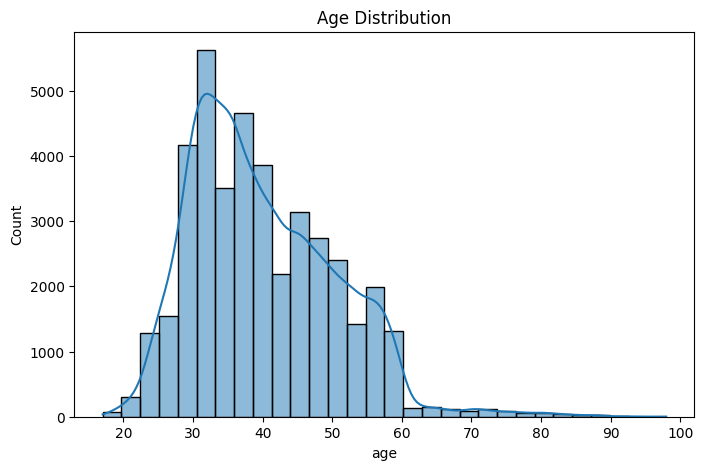

In [14]:
#Univariate analysis with a minimum of three visualizations
plt.figure(figsize=(8, 5))

sns.histplot(
    bank_data["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

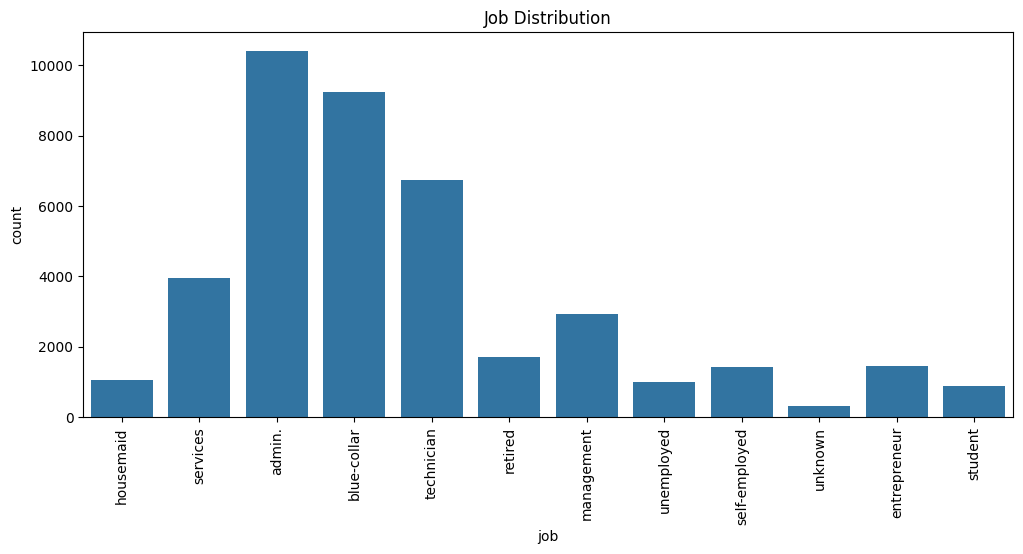

In [15]:
#Univariate analysis with a minimum of three visualizations
plt.figure(figsize=(12, 5))

sns.countplot(
    x="job",
    data=bank_data
)

plt.xticks(rotation=90)

plt.title("Job Distribution")

plt.show()

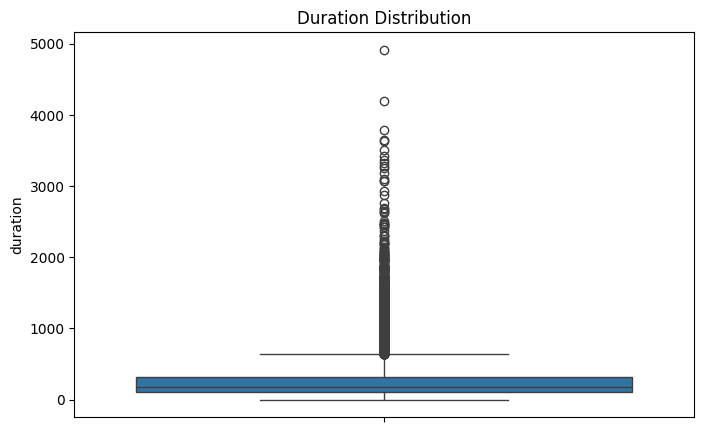

In [16]:
#Univariate analysis with a minimum of three visualizations
plt.figure(figsize=(8, 5))

sns.boxplot(
    y=bank_data["duration"]
)

plt.title("Duration Distribution")

plt.show()

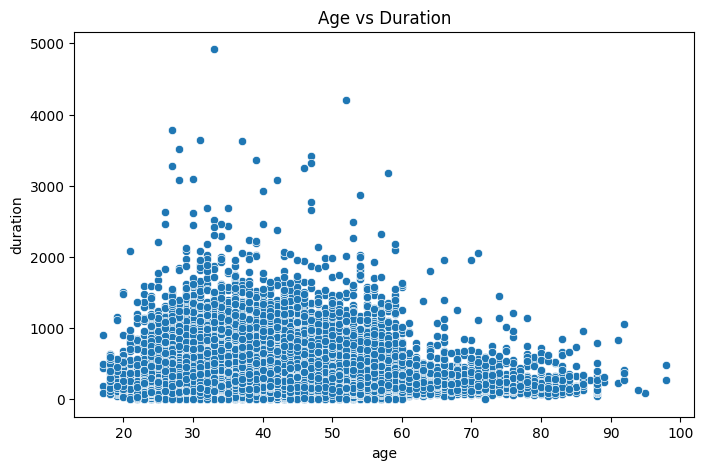

In [17]:
#Bivariate analysis with a minimum of three visualizations
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="age",
    y="duration",
    data=bank_data
)

plt.title("Age vs Duration")

plt.show()

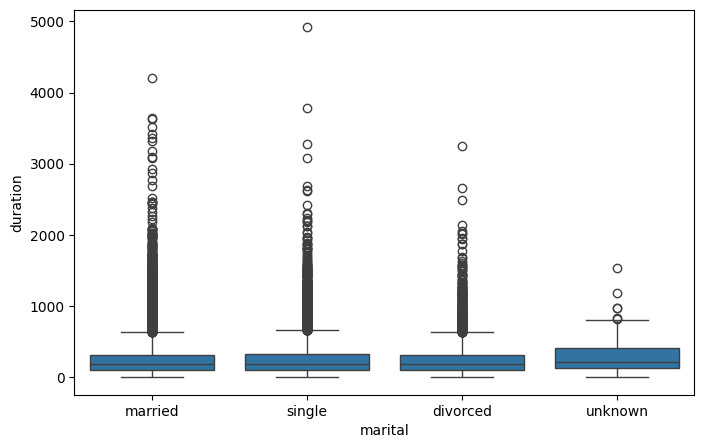

In [ ]:
#Bivariate analysis with a minimum of three visualizations
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="marital",
    y="duration",
    data=bank_data
)

plt.show()

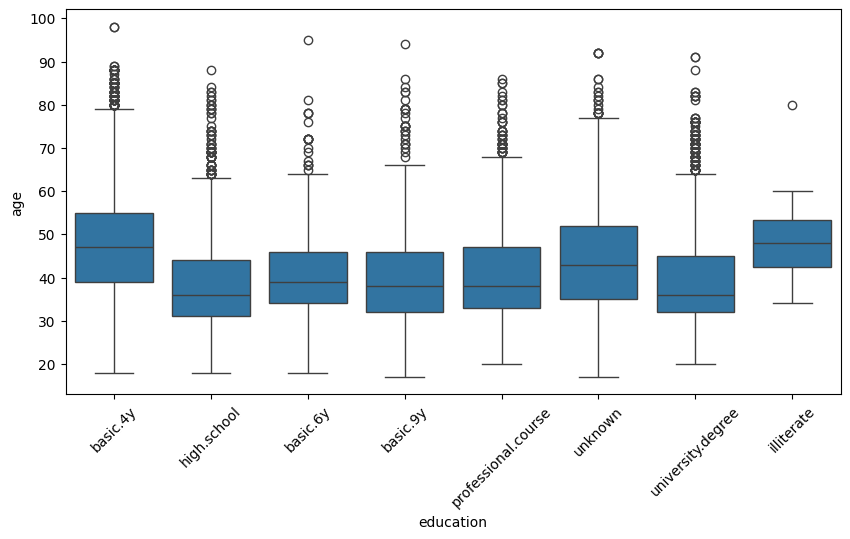

In [18]:
#Bivariate analysis with a minimum of three visualizations
plt.figure(figsize=(10, 5))

sns.boxplot(
    x="education",
    y="age",
    data=bank_data
)

plt.xticks(rotation=45)

plt.show()

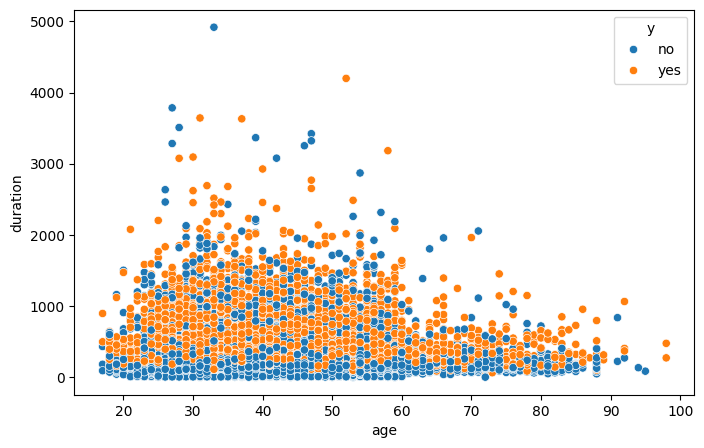

In [19]:
#Multivariate analysis with a minimum of three visualizations
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="age",
    y="duration",
    hue="y",
    data=bank_data
)

plt.show()

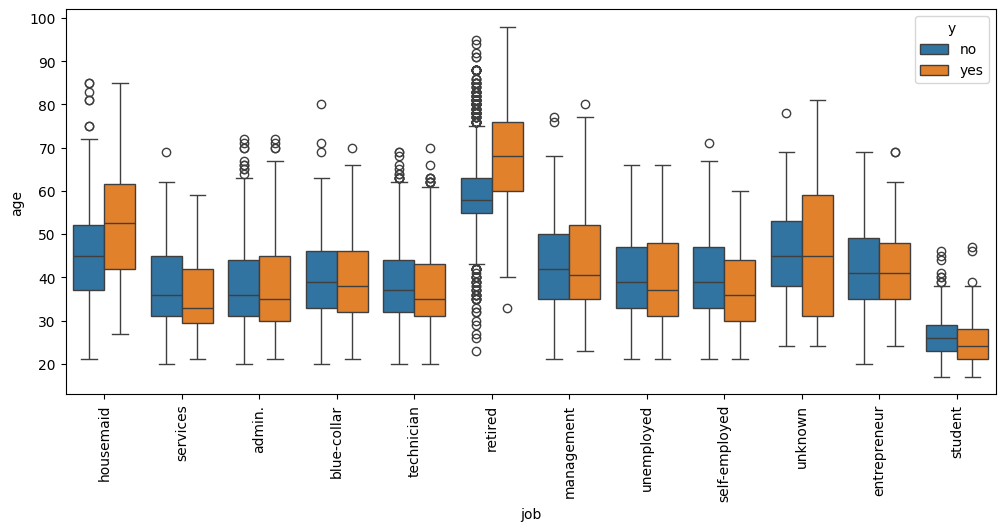

In [20]:
#Multivariate analysis with a minimum of three visualizations
plt.figure(figsize=(12, 5))

sns.boxplot(
    x="job",
    y="age",
    hue="y",
    data=bank_data
)

plt.xticks(rotation=90)

plt.show()

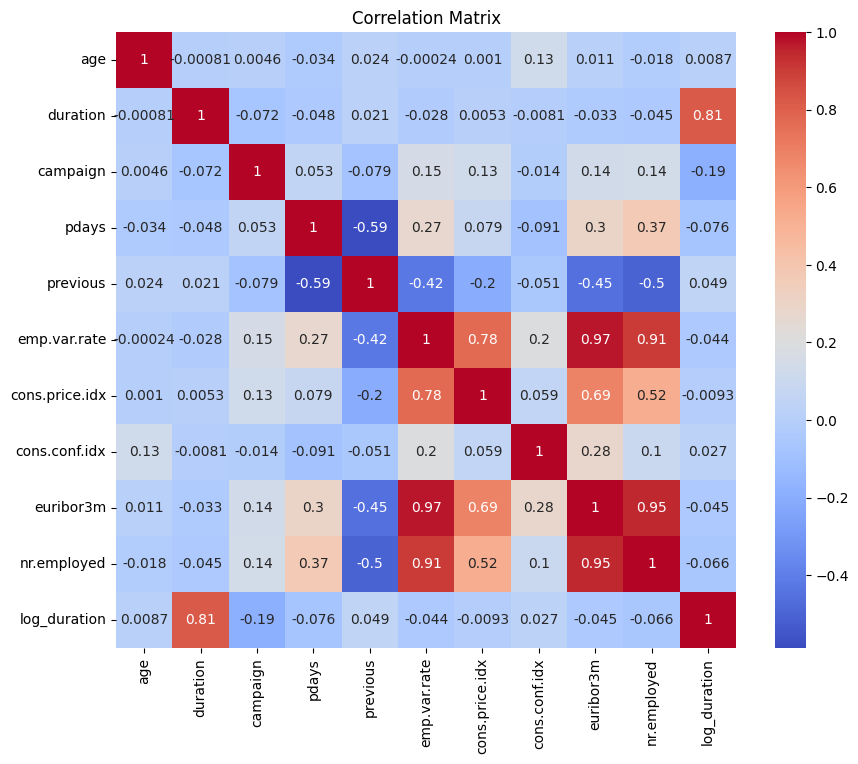

In [21]:
#Multivariate analysis with a minimum of three visualizations
plt.figure(figsize=(10, 8))

numerical_columns = bank_data.select_dtypes(
    include=["int64", "float64"]
)

correlation_matrix = numerical_columns.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Phase II of your BCSE331L - Exploratory Data Analysis (TH)

In [35]:
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [36]:
#1D Statistical Analysis (Univariate)
#Measures of central tendency, dispersion and shape for every numerical column
numeric_features = ["age", "duration", "campaign", "pdays", "previous",
                    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

one_d_stats = pd.DataFrame({
    "mean": bank_data[numeric_features].mean(),
    "median": bank_data[numeric_features].median(),
    "mode": bank_data[numeric_features].mode().iloc[0],
    "variance": bank_data[numeric_features].var(),
    "std_dev": bank_data[numeric_features].std(),
    "range": bank_data[numeric_features].max() - bank_data[numeric_features].min(),
    "Q1": bank_data[numeric_features].quantile(0.25),
    "Q3": bank_data[numeric_features].quantile(0.75),
    "IQR": bank_data[numeric_features].quantile(0.75) - bank_data[numeric_features].quantile(0.25),
    "skewness": bank_data[numeric_features].skew(),
    "kurtosis": bank_data[numeric_features].kurt(),
    "coeff_of_variation": bank_data[numeric_features].std() / bank_data[numeric_features].mean()
})

print(one_d_stats.round(3))

                    mean    median      mode   variance  std_dev     range  \
age               40.024    38.000    31.000    108.591   10.421    81.000   
duration         258.316   180.000    85.000  67239.249  259.305  4918.000   
campaign           2.568     2.000     1.000      7.675    2.770    55.000   
pdays            962.465   999.000   999.000  34945.480  186.937   999.000   
previous           0.173     0.000     0.000      0.245    0.495     7.000   
emp.var.rate       0.082     1.100     1.400      2.468    1.571     4.800   
cons.price.idx    93.576    93.749    93.994      0.335    0.579     2.566   
cons.conf.idx    -40.503   -41.800   -36.400     21.417    4.628    23.900   
euribor3m          3.621     4.857     4.857      3.008    1.734     4.411   
nr.employed     5167.035  5191.000  5228.100   5220.260   72.251   264.500   

                      Q1        Q3      IQR  skewness  kurtosis  \
age               32.000    47.000   15.000     0.785     0.791   
duratio

In [37]:
#Outlier detection using the IQR rule
for column in numeric_features:
    q1 = bank_data[column].quantile(0.25)
    q3 = bank_data[column].quantile(0.75)
    iqr = q3 - q1
    outliers = bank_data[
        (bank_data[column] < q1 - 1.5 * iqr) |
        (bank_data[column] > q3 + 1.5 * iqr)
    ]
    print(column, "-> outliers:", len(outliers))

#Frequency and relative frequency of categorical columns
categorical_features = ["job", "marital", "education", "default", "housing", "loan",
                        "contact", "month", "day_of_week", "poutcome", "y"]

for column in categorical_features:
    frequency_table = pd.DataFrame({
        "count": bank_data[column].value_counts(),
        "percent": bank_data[column].value_counts(normalize=True).mul(100).round(2)
    })
    print("\nFrequency table for", column)
    print(frequency_table)

#Normality test (Shapiro-Wilk on a sample of 5000 rows)
for column in ["age", "duration", "log_duration"]:
    statistic, p_value = stats.shapiro(bank_data[column].sample(5000, random_state=42))
    print(column, "-> W =", round(statistic, 4), ", p-value =", p_value)

age -> outliers: 468
duration -> outliers: 2963
campaign -> outliers: 2406
pdays -> outliers: 1515
previous -> outliers: 5625
emp.var.rate -> outliers: 0
cons.price.idx -> outliers: 0
cons.conf.idx -> outliers: 446
euribor3m -> outliers: 0
nr.employed -> outliers: 0

Frequency table for job
               count  percent
job                          
admin.         10419    25.30
blue-collar     9253    22.47
technician      6739    16.37
services        3967     9.63
management      2924     7.10
retired         1718     4.17
entrepreneur    1456     3.54
self-employed   1421     3.45
housemaid       1060     2.57
unemployed      1014     2.46
student          875     2.13
unknown          330     0.80

Frequency table for marital
          count  percent
marital                 
married   24921    60.52
single    11564    28.08
divorced   4611    11.20
unknown      80     0.19

Frequency table for education
                     count  percent
education                          
univer

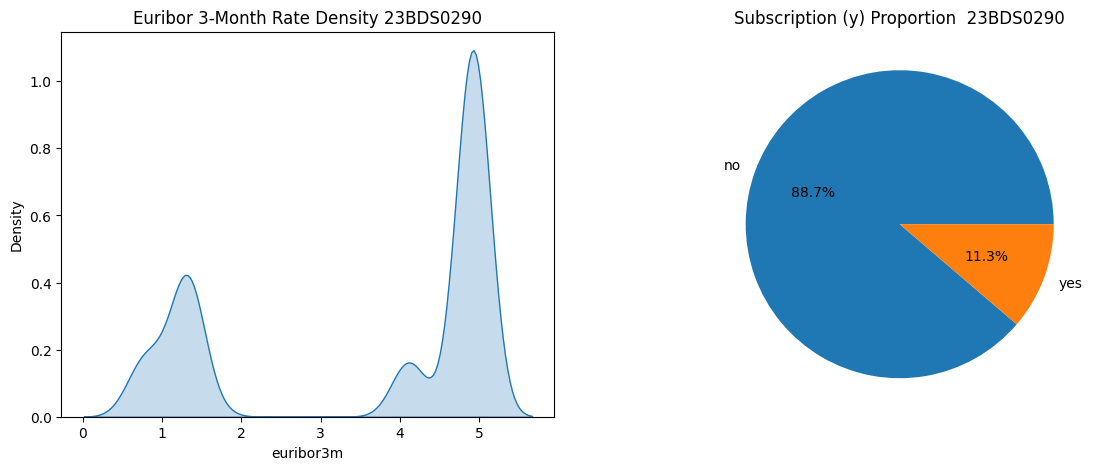

In [38]:
#1D visualization: KDE of euribor3m and pie chart of the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(
    bank_data["euribor3m"],
    fill=True,
    ax=axes[0]
)
axes[0].set_title("Euribor 3-Month Rate Density 23BDS0290")

bank_data["y"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[1]
)
axes[1].set_title("Subscription (y) Proportion  23BDS0290")
axes[1].set_ylabel("")

plt.show()

Covariance matrix:
                   age  duration  campaign     pdays  previous  emp.var.rate  \
age             108.59     -2.18      0.13    -66.97      0.13         -0.00   
duration         -2.18  67239.25    -51.55  -2305.23      2.64        -11.38   
campaign          0.13    -51.55      7.67     27.24     -0.11          0.66   
pdays           -66.97  -2305.23     27.24  34945.48    -54.36         79.60   
previous          0.13      2.64     -0.11    -54.36      0.24         -0.33   
emp.var.rate     -0.00    -11.38      0.66     79.60     -0.33          2.47   
cons.price.idx    0.01      0.80      0.20      8.54     -0.06          0.70   
cons.conf.idx     6.22     -9.75     -0.18    -79.05     -0.12          1.43   
euribor3m         0.20    -14.78      0.65     96.28     -0.39          2.65   
nr.employed     -13.26   -836.93     28.85   5033.31    -17.93        102.94   

                cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
age                       0.

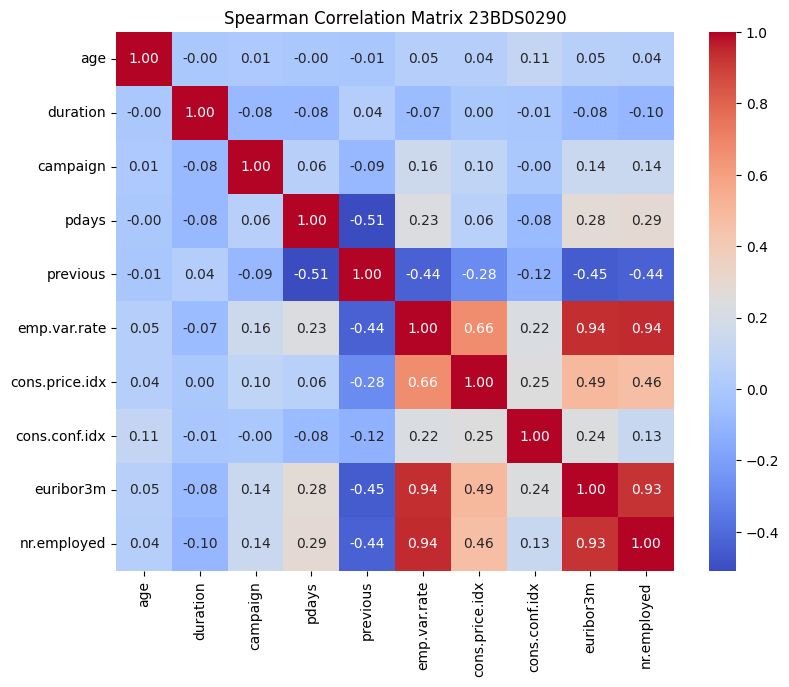

In [39]:
#2D Statistical Analysis (Bivariate)
#Covariance matrix
print("Covariance matrix:")
print(bank_data[numeric_features].cov().round(2))

#Pearson and Spearman correlation between euribor3m and nr.employed
pearson_r, pearson_p = stats.pearsonr(bank_data["euribor3m"], bank_data["nr.employed"])
spearman_r, spearman_p = stats.spearmanr(bank_data["euribor3m"], bank_data["nr.employed"])

print("\nPearson  (euribor3m, nr.employed): r =", round(pearson_r, 4), ", p =", pearson_p)
print("Spearman (euribor3m, nr.employed): rho =", round(spearman_r, 4), ", p =", spearman_p)

#Spearman correlation heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    bank_data[numeric_features].corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Spearman Correlation Matrix 23BDS0290")
plt.show()

In [40]:
#Numerical vs categorical: group statistics
print(bank_data.groupby("y")[numeric_features].agg(["mean", "median"]).round(2).T)

#Independent t-test: does call duration differ between subscribers and non-subscribers?
duration_yes = bank_data[bank_data["y"] == "yes"]["duration"]
duration_no = bank_data[bank_data["y"] == "no"]["duration"]

t_stat, t_p = stats.ttest_ind(duration_yes, duration_no, equal_var=False)
print("\nWelch t-test (duration by y): t =", round(t_stat, 3), ", p =", t_p)

#One-way ANOVA: does age differ across education levels?
education_groups = [group["age"].values for _, group in bank_data.groupby("education")]
f_stat, f_p = stats.f_oneway(*education_groups)
print("ANOVA (age by education): F =", round(f_stat, 3), ", p =", f_p)

#Categorical vs categorical: contingency table and chi-square test
contingency_table = pd.crosstab(bank_data["job"], bank_data["y"])
print("\nContingency table (job vs y):")
print(contingency_table)

chi2, chi_p, dof, expected = stats.chi2_contingency(contingency_table)
print("\nChi-square (job vs y): chi2 =", round(chi2, 3), ", dof =", dof, ", p =", chi_p)

y                           no      yes
age            mean      39.91    40.91
               median    38.00    37.00
duration       mean     220.87   553.26
               median   164.00   449.00
campaign       mean       2.63     2.05
               median     2.00     2.00
pdays          mean     984.11   791.99
               median   999.00   999.00
previous       mean       0.13     0.49
               median     0.00     0.00
emp.var.rate   mean       0.25    -1.23
               median     1.10    -1.80
cons.price.idx mean      93.60    93.35
               median    93.92    93.20
cons.conf.idx  mean     -40.59   -39.79
               median   -41.80   -40.40
euribor3m      mean       3.81     2.12
               median     4.86     1.27
nr.employed    mean    5176.17  5095.12
               median  5195.80  5099.10

Welch t-test (duration by y): t = 55.498 , p = 0.0
ANOVA (age by education): F = 457.366 , p = 0.0

Contingency table (job vs y):
y                no   yes
job

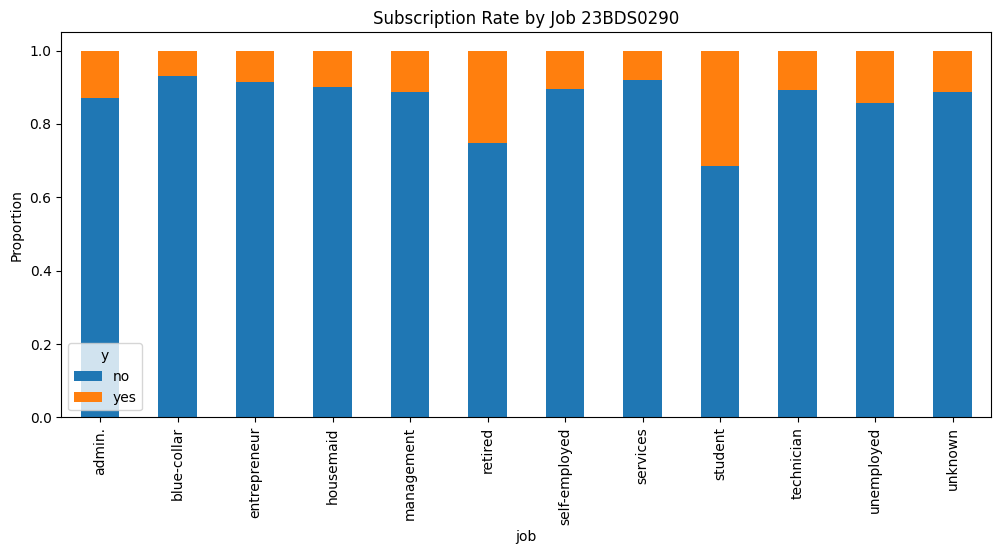

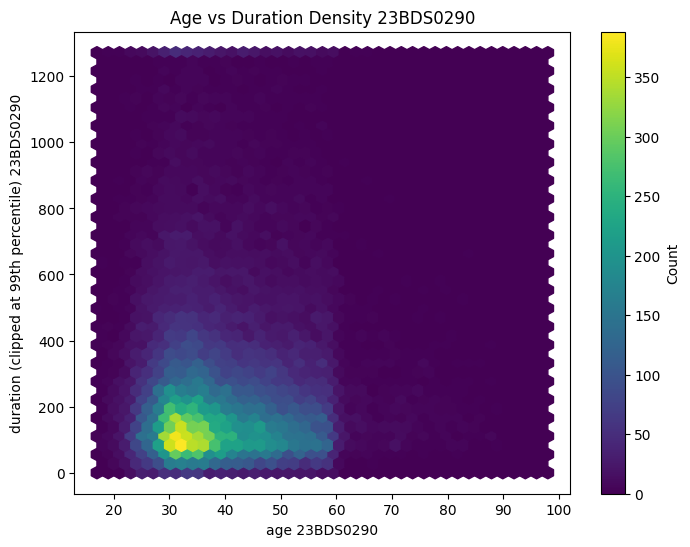

In [41]:
#Stacked bar chart of subscription rate by job
pd.crosstab(bank_data["job"], bank_data["y"], normalize="index").plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5)
)

plt.title("Subscription Rate by Job 23BDS0290")
plt.ylabel("Proportion")
plt.show()

#Hexbin plot for age vs duration (dense 2D distribution)
plt.figure(figsize=(8, 6))

plt.hexbin(
    bank_data["age"],
    bank_data["duration"].clip(upper=bank_data["duration"].quantile(0.99)),
    gridsize=40,
    cmap="viridis"
)

plt.colorbar(label="Count")
plt.xlabel("age 23BDS0290")
plt.ylabel("duration (clipped at 99th percentile) 23BDS0290")
plt.title("Age vs Duration Density 23BDS0290")
plt.show()

In [42]:
#3D Statistical Analysis (Trivariate)
#Three-way pivot table: mean duration by age group, marital status and subscription
pivot_3d = pd.pivot_table(
    bank_data,
    values="duration",
    index=["age_group", "marital"],
    columns="y",
    aggfunc="mean",
    observed=True
)

print(pivot_3d.round(2))

#Three-way contingency table: housing loan x personal loan x subscription
print(pd.crosstab(
    [bank_data["housing"], bank_data["loan"]],
    bank_data["y"],
    margins=True
))

#Partial correlation between euribor3m and nr.employed, controlling for emp.var.rate
def partial_correlation(data, x, y, z):
    r_xy = data[x].corr(data[y])
    r_xz = data[x].corr(data[z])
    r_yz = data[y].corr(data[z])
    return (r_xy - r_xz * r_yz) / np.sqrt((1 - r_xz ** 2) * (1 - r_yz ** 2))

print("\nPartial correlation (euribor3m, nr.employed | emp.var.rate):",
      round(partial_correlation(bank_data, "euribor3m", "nr.employed", "emp.var.rate"), 4))

#Grouped statistics across three variables: duration by education and y
print(bank_data.groupby(["education", "y"])["duration"].agg(["mean", "std", "count"]).round(2))

y                       no      yes
age_group marital                  
Young     divorced  219.83   568.61
          married   223.58   596.47
          single    221.44   467.47
          unknown   220.10   447.33
Adult     divorced  218.80   637.21
          married   221.62   624.91
          single    218.49   577.71
          unknown   222.88   451.00
Middle    divorced  220.42   562.94
          married   220.26   596.58
          single    227.55   502.10
          unknown   318.65  1356.00
Senior    divorced  212.71   329.49
          married   213.75   344.20
          single    286.95   353.10
          unknown   340.00   810.00
y                   no   yes    All
housing loan                       
no      no       14307  1751  16058
        yes       2283   274   2557
unknown unknown    883   107    990
yes     no       15782  2098  17880
        yes       3282   409   3691
All              36537  4639  41176

Partial correlation (euribor3m, nr.employed | emp.var.rate): 0.

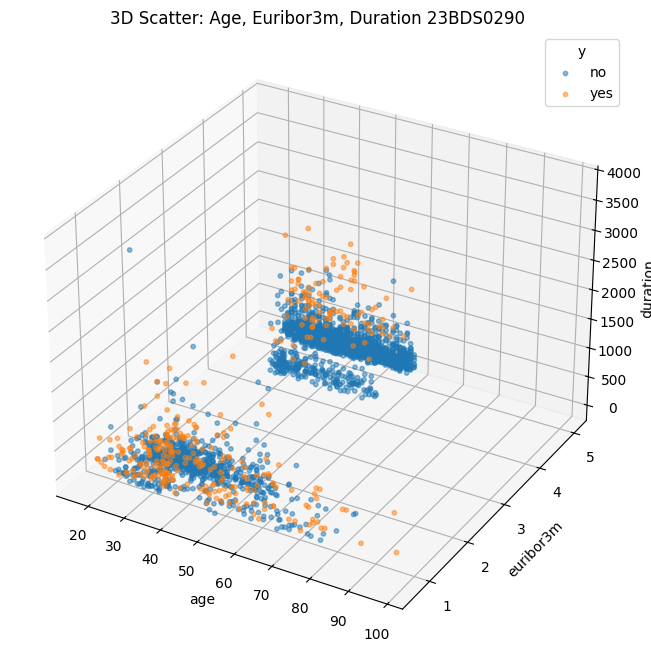

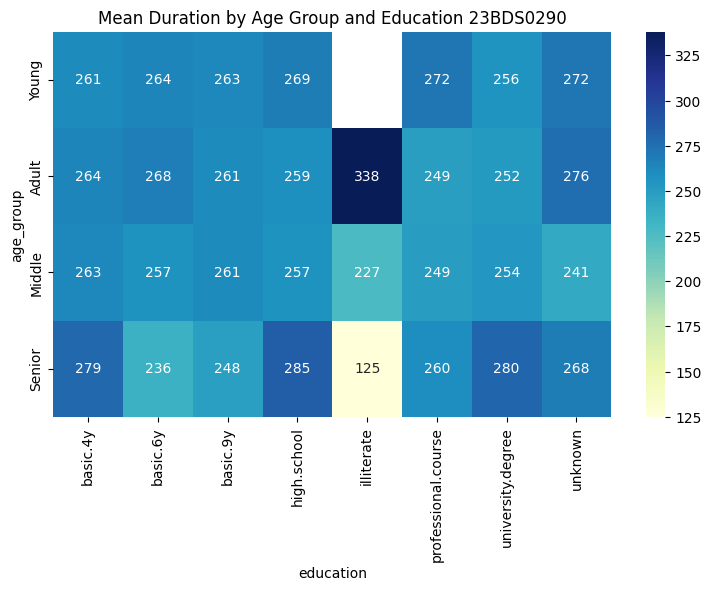

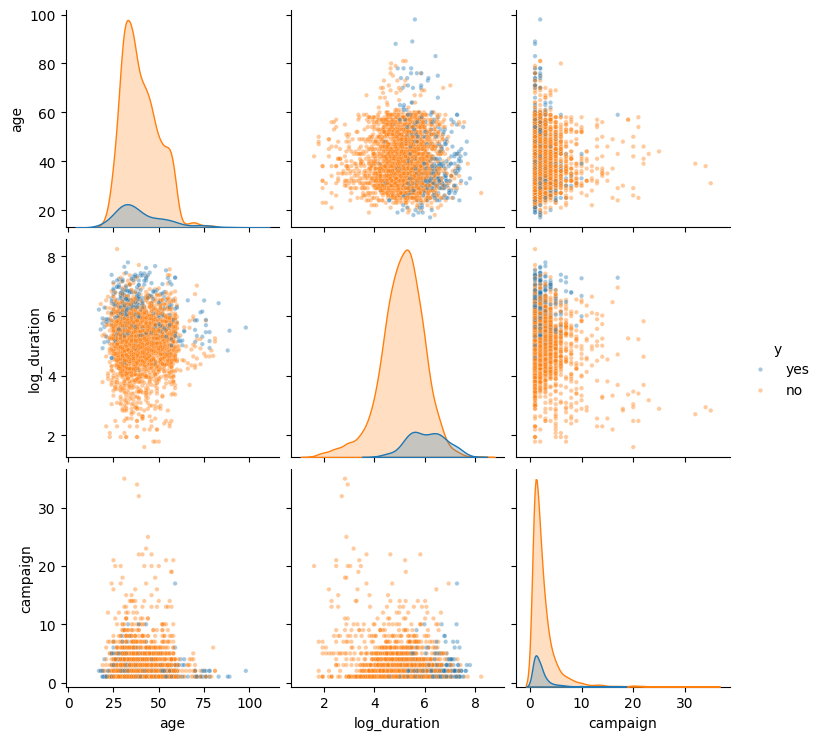

In [43]:
#3D scatter plot: age, euribor3m and duration coloured by subscription
sample_3d = bank_data.sample(3000, random_state=42)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

for label, colour in [("no", "tab:blue"), ("yes", "tab:orange")]:
    subset = sample_3d[sample_3d["y"] == label]
    ax.scatter(
        subset["age"],
        subset["euribor3m"],
        subset["duration"],
        c=colour,
        label=label,
        alpha=0.5,
        s=10
    )

ax.set_xlabel("age")
ax.set_ylabel("euribor3m")
ax.set_zlabel("duration")
ax.set_title("3D Scatter: Age, Euribor3m, Duration 23BDS0290")
ax.legend(title="y")
plt.show()

#Heatmap of mean duration across age group and education
plt.figure(figsize=(9, 5))

sns.heatmap(
    pd.pivot_table(
        bank_data,
        values="duration",
        index="age_group",
        columns="education",
        aggfunc="mean",
        observed=True
    ),
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Mean Duration by Age Group and Education 23BDS0290")
plt.show()

#Pair plot of three numerical variables with hue
sns.pairplot(
    sample_3d[["age", "log_duration", "campaign", "y"]],
    hue="y",
    plot_kws={"alpha": 0.4, "s": 10}
)

plt.show()

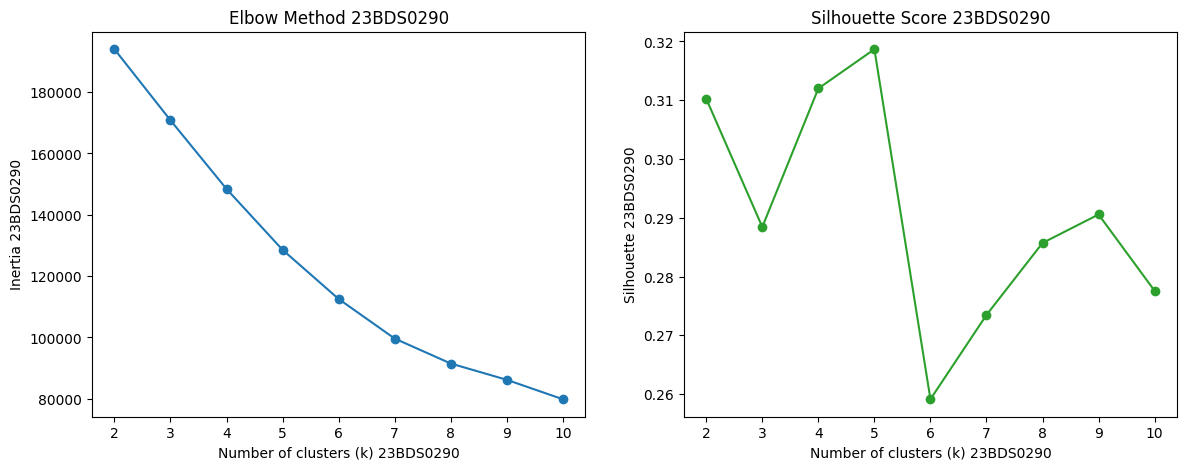

In [44]:
#K-Means Clustering
#Selecting and scaling features for clustering
cluster_features = ["age", "duration", "campaign", "previous", "euribor3m", "cons.conf.idx"]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(bank_data[cluster_features])

#Elbow method and silhouette score to choose k
inertia_values = []
silhouette_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans_model = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans_labels = kmeans_model.fit_predict(scaled_data)
    inertia_values.append(kmeans_model.inertia_)
    silhouette_values.append(
        silhouette_score(scaled_data, kmeans_labels, sample_size=5000, random_state=42)
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia_values, marker="o")
axes[0].set_title("Elbow Method 23BDS0290")
axes[0].set_xlabel("Number of clusters (k) 23BDS0290")
axes[0].set_ylabel("Inertia 23BDS0290")

axes[1].plot(k_range, silhouette_values, marker="o", color="tab:green")
axes[1].set_title("Silhouette Score 23BDS0290")
axes[1].set_xlabel("Number of clusters (k) 23BDS0290")
axes[1].set_ylabel("Silhouette 23BDS0290")

plt.show()

Cluster sizes:
kmeans_cluster
0    26705
1     7228
2     1631
3     5612
Name: count, dtype: int64

Cluster profiles (mean of original features):
                  age  duration  campaign  previous  euribor3m  cons.conf.idx
kmeans_cluster                                                               
0               40.43    259.06      2.19      0.00       4.63         -38.93
1               38.09    267.44      2.14      0.00       1.28         -45.51
2               40.42    178.70     12.78      0.01       4.76         -40.11
3               40.45    266.16      1.94      1.27       1.49         -41.66

Subscription rate per cluster:
y                  no    yes
kmeans_cluster              
0               0.936  0.064
1               0.812  0.188
2               0.963  0.037
3               0.733  0.267

Explained variance ratio: [0.266 0.187]


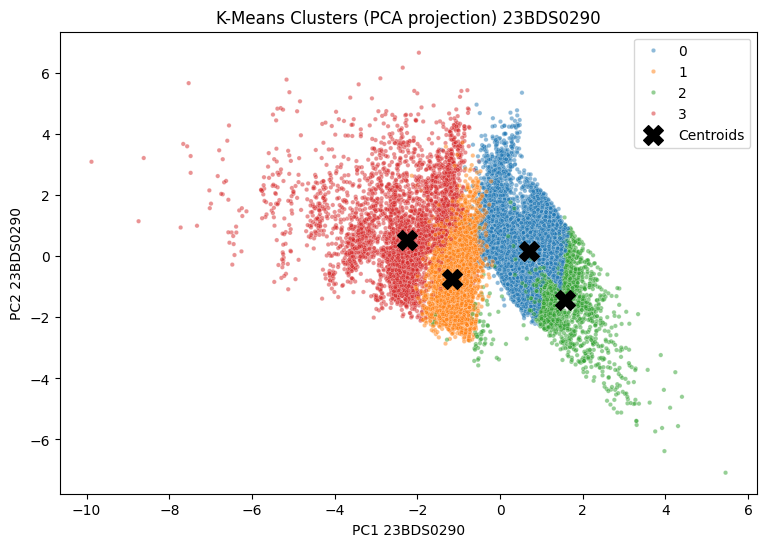

In [45]:
#Fitting the final K-Means model
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
bank_data["kmeans_cluster"] = kmeans.fit_predict(scaled_data)

print("Cluster sizes:")
print(bank_data["kmeans_cluster"].value_counts().sort_index())

print("\nCluster profiles (mean of original features):")
print(bank_data.groupby("kmeans_cluster")[cluster_features].mean().round(2))

print("\nSubscription rate per cluster:")
print(pd.crosstab(bank_data["kmeans_cluster"], bank_data["y"], normalize="index").round(3))

#Visualising the clusters in 2D using PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

print("\nExplained variance ratio:", pca.explained_variance_ratio_.round(3))

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=pca_components[:, 0],
    y=pca_components[:, 1],
    hue=bank_data["kmeans_cluster"],
    palette="tab10",
    s=10,
    alpha=0.5
)

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="black",
    marker="X",
    s=200,
    label="Centroids"
)

plt.title("K-Means Clusters (PCA projection) 23BDS0290")
plt.xlabel("PC1 23BDS0290")
plt.ylabel("PC2 23BDS0290")
plt.legend()
plt.show()

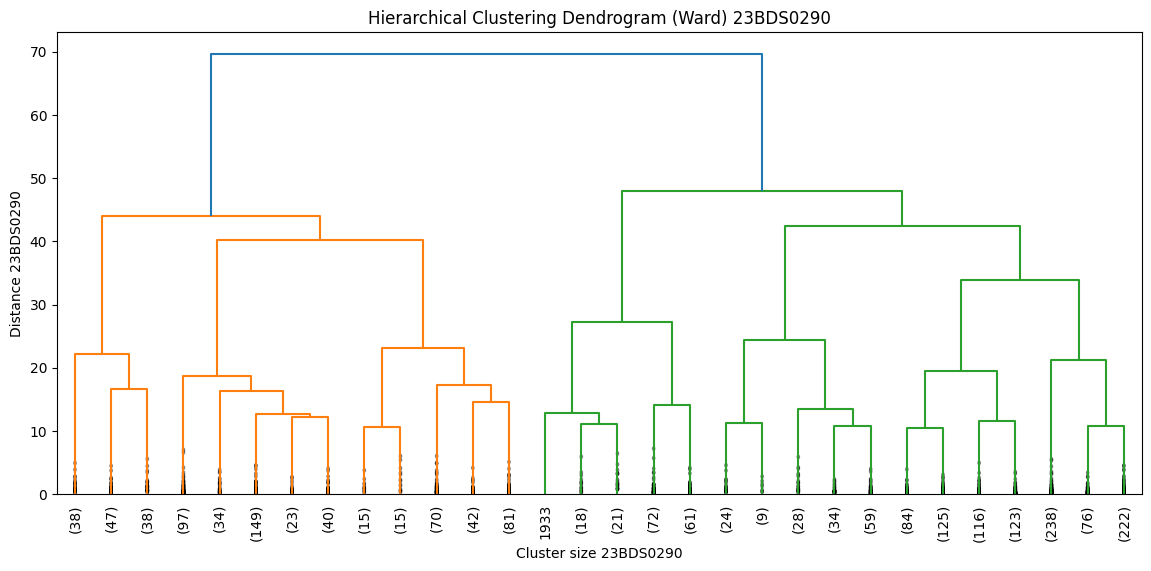

ward linkage -> silhouette = 0.3072
complete linkage -> silhouette = 0.521
average linkage -> silhouette = 0.5363
single linkage -> silhouette = 0.6777


In [46]:
#Hierarchical Clustering
#Hierarchical clustering is O(n^2) in memory, so a random sample of 2000 rows is used
sample_index = bank_data.sample(2000, random_state=42).index
sample_scaled = scaled_data[bank_data.index.get_indexer(sample_index)]

#Dendrogram using Ward linkage
linkage_matrix = linkage(sample_scaled, method="ward")

plt.figure(figsize=(14, 6))

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram (Ward) 23BDS0290")
plt.xlabel("Cluster size 23BDS0290")
plt.ylabel("Distance 23BDS0290")
plt.show()

#Comparing linkage methods using silhouette score
for method in ["ward", "complete", "average", "single"]:
    agglomerative = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)
    labels = agglomerative.fit_predict(sample_scaled)
    print(method, "linkage -> silhouette =", round(silhouette_score(sample_scaled, labels), 4))


Hierarchical cluster sizes:
hierarchical_cluster
0     123
1     566
2     173
3    1138
Name: count, dtype: int64

Hierarchical cluster profiles:
                        age  duration  campaign  previous  euribor3m  \
hierarchical_cluster                                                   
0                     43.80    223.48      1.85      0.49       0.80   
1                     39.25    240.69      2.13      0.50       1.48   
2                     41.04    902.71      2.19      0.06       4.30   
3                     39.97    195.83      2.91      0.00       4.83   

                      cons.conf.idx  
hierarchical_cluster                 
0                            -30.96  
1                            -45.01  
2                            -40.13  
3                            -39.39  

Adjusted Rand Index (K-Means vs Hierarchical): 0.562


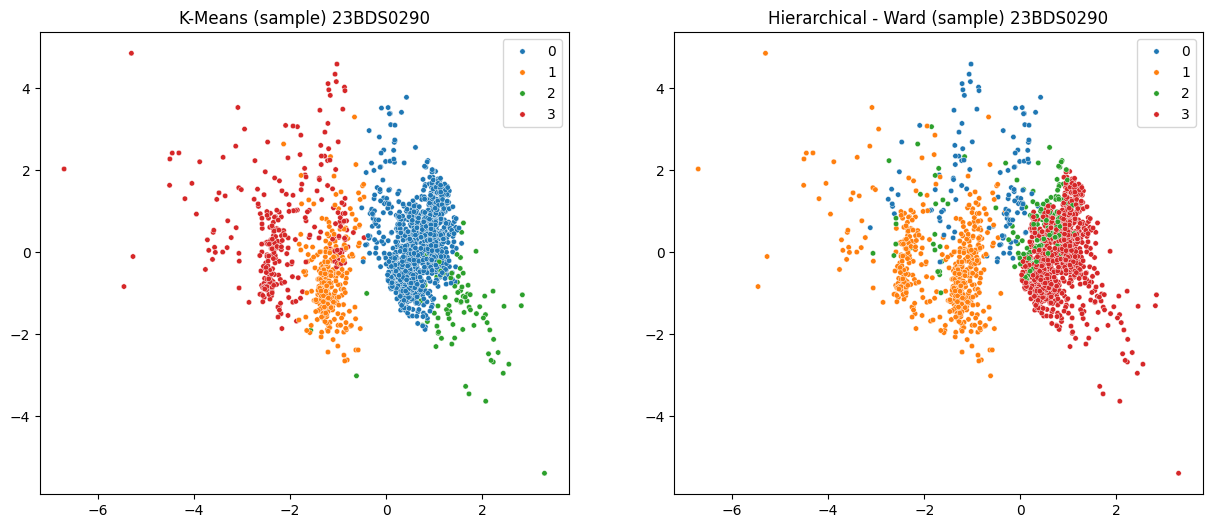

In [47]:
#Final hierarchical model with Ward linkage
hierarchical_labels = fcluster(linkage_matrix, t=optimal_k, criterion="maxclust") - 1

hierarchical_sample = bank_data.loc[sample_index].copy()
hierarchical_sample["hierarchical_cluster"] = hierarchical_labels

print("\nHierarchical cluster sizes:")
print(hierarchical_sample["hierarchical_cluster"].value_counts().sort_index())

print("\nHierarchical cluster profiles:")
print(hierarchical_sample.groupby("hierarchical_cluster")[cluster_features].mean().round(2))

#Agreement between K-Means and Hierarchical clustering on the same sample
print("\nAdjusted Rand Index (K-Means vs Hierarchical):",
      round(adjusted_rand_score(hierarchical_sample["kmeans_cluster"], hierarchical_labels), 4))

#Side-by-side PCA view of both clusterings
sample_pca = pca.transform(sample_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    x=sample_pca[:, 0],
    y=sample_pca[:, 1],
    hue=hierarchical_sample["kmeans_cluster"].values,
    palette="tab10",
    s=15,
    ax=axes[0]
)
axes[0].set_title("K-Means (sample) 23BDS0290")

sns.scatterplot(
    x=sample_pca[:, 0],
    y=sample_pca[:, 1],
    hue=hierarchical_labels,
    palette="tab10",
    s=15,
    ax=axes[1]
)
axes[1].set_title("Hierarchical - Ward (sample) 23BDS0290")

plt.show()